In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install scipy pillow tqdm

In [ ]:
!pip install matplotlib

## 1. Imports & Configuration

In [ ]:
import os, glob, itertools, random, time, copy
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
BASE          = '/content/'
MONET_DIR     = os.path.join(BASE, '/content/monet_jpg')
PHOTO_DIR     = os.path.join(BASE, '/content/drive/MyDrive/photo_jpg')
PRED_A2B_DIR  = os.path.join(BASE, '/content/drive/MyDrive/pred_A2B_kedar')
PRED_B2A_DIR  = os.path.join(BASE, '/content/drive/MyDrive/pred_B2A_kedar')

os.makedirs(PRED_A2B_DIR, exist_ok=True)
os.makedirs(PRED_B2A_DIR, exist_ok=True)

IMG_SIZE      = 256
BATCH_SIZE    = 1
N_EPOCHS      = 50
N_EPOCHS_DECAY= 50
LR            = 2e-4
D_LR          = 1e-4
LAMBDA_CYCLE  = 10.0
LAMBDA_IDENTITY = 1.0
POOL_SIZE     = 50
SAVE_EVERY    = 10
EMA_DECAY     = 0.9995
N_GEN_IMAGES  = 300

CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Config loaded.')
print(f'Training for {N_EPOCHS + N_EPOCHS_DECAY} total epochs')

Config loaded.
Training for 100 total epochs


## 2. Dataset & Transforms

In [ ]:
train_transform = T.Compose([
    T.Resize(int(IMG_SIZE * 1.12), T.InterpolationMode.BICUBIC),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

infer_transform = T.Compose([
    T.Resize(IMG_SIZE, T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


class UnpairedDataset(Dataset):
    def __init__(self, dir_A, dir_B, transform=None):
        exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
        self.paths_A = sorted(sum([glob.glob(os.path.join(dir_A, e)) for e in exts], []))
        self.paths_B = sorted(sum([glob.glob(os.path.join(dir_B, e)) for e in exts], []))
        self.transform = transform
        print(f'Domain A: {len(self.paths_A)} images | Domain B: {len(self.paths_B)} images')

    def __len__(self):
        return max(len(self.paths_A), len(self.paths_B))

    def __getitem__(self, idx):
        img_A = Image.open(self.paths_A[idx % len(self.paths_A)]).convert('RGB')
        img_B = Image.open(self.paths_B[random.randint(0, len(self.paths_B)-1)]).convert('RGB')
        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)
        return img_A, img_B


train_dataset = UnpairedDataset(MONET_DIR, PHOTO_DIR, transform=train_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
print(f'Batches per epoch: {len(train_loader)}')

Domain A: 300 images | Domain B: 7038 images
Batches per epoch: 7038


## 3. Model Architecture(Generator Resnet and Discriminator PatchGAN)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, n_res=9, ngf=64):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, ngf, 7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True)
        ]

        for mult in [1, 2]:
            layers += [
                nn.Conv2d(ngf * mult, ngf * mult * 2, 3, stride=2, padding=1),
                nn.InstanceNorm2d(ngf * mult * 2),
                nn.ReLU(inplace=True)
            ]

        for _ in range(n_res):
            layers.append(ResidualBlock(ngf * 4))

        for mult in [4, 2]:
            layers += [
                nn.ConvTranspose2d(ngf * mult, ngf * (mult // 2), 3,
                                   stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(ngf * (mult // 2)),
                nn.ReLU(inplace=True)
            ]

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, out_ch, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self, in_ch=3, ndf=64):
        super().__init__()

        def disc_block(in_f, out_f, norm=True, stride=2):
            layers = [nn.utils.spectral_norm(nn.Conv2d(in_f, out_f, 4, stride=stride, padding=1))]
            if norm:
                layers.append(nn.InstanceNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *disc_block(in_ch,     ndf,     norm=False),
            *disc_block(ndf,       ndf*2),
            *disc_block(ndf*2,     ndf*4),
            *disc_block(ndf*4,     ndf*8,   stride=1),
            nn.utils.spectral_norm(nn.Conv2d(ndf*8, 1, 4, padding=1))
        )

    def forward(self, x):
        return self.model(x)


G_A2B = Generator().to(device)
G_B2A = Generator().to(device)
D_A   = Discriminator().to(device)
D_B   = Discriminator().to(device)
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.InstanceNorm2d) and m.weight is not None:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

for net in [G_A2B, G_B2A, D_A, D_B]:
    net.apply(weights_init)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'Generator params  : {count_params(G_A2B):,}')
print(f'Discriminator params: {count_params(D_A):,}')

Generator params  : 11,378,179
Discriminator params: 2,764,737


## 4. Loss Functions & Optimisers

In [ ]:
criterion_GAN    = nn.MSELoss()
criterion_cycle  = nn.L1Loss()
criterion_identity = nn.L1Loss()
opt_G = optim.Adam(
    itertools.chain(G_A2B.parameters(), G_B2A.parameters()),
    lr=LR, betas=(0.5, 0.999)
)
opt_D_A = optim.Adam(D_A.parameters(), lr=D_LR, betas=(0.5, 0.999))
opt_D_B = optim.Adam(D_B.parameters(), lr=D_LR, betas=(0.5, 0.999))

import math

def lambda_rule(epoch):
    if epoch < N_EPOCHS:
        return 1.0
    progress = (epoch - N_EPOCHS) / float(N_EPOCHS_DECAY)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

sched_G   = optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda=lambda_rule)
sched_D_A = optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda=lambda_rule)
sched_D_B = optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda=lambda_rule)

print('Losses, optimisers, and schedulers initialised.')


class ImagePool:
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images    = []

    def query(self, images):
        if self.pool_size == 0:
            return images
        out = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.pool_size:
                self.images.append(img)
                out.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, len(self.images)-1)
                tmp = self.images[idx].clone()
                self.images[idx] = img
                out.append(tmp)
            else:
                out.append(img)
        return torch.cat(out, 0)

pool_A = ImagePool(POOL_SIZE)
pool_B = ImagePool(POOL_SIZE)

Losses, optimisers, and schedulers initialised.


## 5. Training Loop and Generate Images

In [ ]:
def set_requires_grad(nets, requires_grad):
    for net in nets:
        for param in net.parameters():
            param.requires_grad = requires_grad


def save_checkpoint(epoch):
    torch.save({
        'epoch': epoch,
        'G_A2B': G_A2B.state_dict(),
        'G_B2A': G_B2A.state_dict(),
        'D_A':   D_A.state_dict(),
        'D_B':   D_B.state_dict(),
        'opt_G':    opt_G.state_dict(),
        'opt_D_A':  opt_D_A.state_dict(),
        'opt_D_B':  opt_D_B.state_dict(),
    }, os.path.join(CHECKPOINT_DIR, f'epoch_{epoch:03d}.pth'))
    print(f'  ✓ Checkpoint saved at epoch {epoch}')


def load_checkpoint(path):
    ck = torch.load(path, map_location=device)
    G_A2B.load_state_dict(ck['G_A2B'])
    G_B2A.load_state_dict(ck['G_B2A'])
    D_A.load_state_dict(ck['D_A'])
    D_B.load_state_dict(ck['D_B'])
    opt_G.load_state_dict(ck['opt_G'])
    opt_D_A.load_state_dict(ck['opt_D_A'])
    opt_D_B.load_state_dict(ck['opt_D_B'])
    print(f'Loaded checkpoint from {path} (epoch {ck["epoch"]})')
    return ck['epoch']


def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

@torch.no_grad()
def generate_images(G, src_dir, out_dir, n_images=300, tag=""):
    os.makedirs(out_dir, exist_ok=True)

    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    src_paths = sorted(sum([glob.glob(os.path.join(src_dir, e)) for e in exts], []))
    if len(src_paths) == 0:
        raise ValueError(f"No images found in {src_dir}")

    G_was_training = G.training
    G.eval()

    for k in tqdm(range(n_images), desc=f"Generating {tag}".strip()):
        p = src_paths[k % len(src_paths)]
        img = Image.open(p).convert("RGB")
        x = infer_transform(img).unsqueeze(0).to(device)
        y = G(x).cpu().squeeze(0)
        y = denorm(y)

        base = os.path.splitext(os.path.basename(p))[0]
        out_name = f"{base}_{k:04d}.jpg" if tag == "" else f"{base}_{tag.replace(' ','_')}_{k:04d}.jpg"
        out_path = os.path.join(out_dir, out_name)

        y_img = (y.permute(1, 2, 0).numpy() * 255.0).astype(np.uint8)
        Image.fromarray(y_img).save(out_path, quality=95)

    if G_was_training:
        G.train()

ema_G_A2B = copy.deepcopy(G_A2B).eval()
ema_G_B2A = copy.deepcopy(G_B2A).eval()
for p in ema_G_A2B.parameters():
    p.requires_grad_(False)
for p in ema_G_B2A.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def update_ema(ema_model, model, decay=EMA_DECAY):
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.data.mul_(decay).add_(p.data, alpha=1 - decay)

print('EMA generators initialised.')

start_epoch = 1

EMA generators initialised.


In [ ]:
history = {'loss_G': [], 'loss_D': [], 'loss_cycle': [], 'loss_identity': []}
total_epochs = N_EPOCHS + N_EPOCHS_DECAY
milestones = [int(len(train_loader) * p) - 1 for p in [0.25, 0.50, 0.75, 1.0]]

for epoch in range(start_epoch, total_epochs + 1):
    G_A2B.train(); G_B2A.train(); D_A.train(); D_B.train()
    epoch_loss_G = epoch_loss_D = epoch_loss_cyc = epoch_loss_idt = 0.0
    d_updates = 0
    latest_D_loss = 0.0
    t0 = time.time()

    for i, (real_A, real_B) in enumerate(train_loader):
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        patch = D_A(real_A).shape
        real_label = torch.ones(patch, device=device) * 0.9
        fake_label = torch.zeros(patch, device=device)

        set_requires_grad([D_A, D_B], False)
        opt_G.zero_grad()
        idt_B = G_A2B(real_B); idt_A = G_B2A(real_A)
        loss_idt_A = criterion_identity(idt_A, real_A) * LAMBDA_CYCLE * LAMBDA_IDENTITY
        loss_idt_B = criterion_identity(idt_B, real_B) * LAMBDA_CYCLE * LAMBDA_IDENTITY
        fake_B = G_A2B(real_A); fake_A = G_B2A(real_B)
        loss_adv_A2B = criterion_GAN(D_B(fake_B), real_label)
        loss_adv_B2A = criterion_GAN(D_A(fake_A), real_label)
        rec_A = G_B2A(fake_B); rec_B = G_A2B(fake_A)
        loss_cyc_A = criterion_cycle(rec_A, real_A) * LAMBDA_CYCLE
        loss_cyc_B = criterion_cycle(rec_B, real_B) * LAMBDA_CYCLE
        loss_G = loss_adv_A2B + loss_adv_B2A + loss_cyc_A + loss_cyc_B + loss_idt_A + loss_idt_B
        loss_G.backward(); opt_G.step()

        update_ema(ema_G_A2B, G_A2B)
        update_ema(ema_G_B2A, G_B2A)

        if i % 2 == 0:
            set_requires_grad([D_A, D_B], True)
            opt_D_A.zero_grad()
            fake_A_pool = pool_A.query(fake_A.detach())
            loss_D_A = 0.5 * (criterion_GAN(D_A(real_A), real_label) + criterion_GAN(D_A(fake_A_pool), fake_label))
            loss_D_A.backward(); opt_D_A.step()
            opt_D_B.zero_grad()
            fake_B_pool = pool_B.query(fake_B.detach())
            loss_D_B = 0.5 * (criterion_GAN(D_B(real_B), real_label) + criterion_GAN(D_B(fake_B_pool), fake_label))
            loss_D_B.backward(); opt_D_B.step()
            epoch_loss_D += (loss_D_A.item() + loss_D_B.item()) / 2
            latest_D_loss = loss_D_A.item() + loss_D_B.item()
            d_updates += 1

        epoch_loss_G   += loss_G.item()
        epoch_loss_cyc += (loss_cyc_A.item() + loss_cyc_B.item()) / 2
        epoch_loss_idt += (loss_idt_A.item() + loss_idt_B.item()) / 2
        del real_label, fake_label, patch

        if i in milestones:
            pct = (milestones.index(i) + 1) * 25
            print(f'  Epoch [{epoch}/{total_epochs}] {pct}% | '
                  f'G={loss_G.item():.3f} D={latest_D_loss:.3f} '
                  f'Cyc={(loss_cyc_A+loss_cyc_B).item():.3f}')

    sched_G.step(); sched_D_A.step(); sched_D_B.step()
    n = len(train_loader)
    history['loss_G'].append(epoch_loss_G / n)
    history['loss_D'].append(epoch_loss_D / max(d_updates, 1))
    history['loss_cycle'].append(epoch_loss_cyc / n)
    history['loss_identity'].append(epoch_loss_idt / n)

    elapsed = time.time() - t0
    print(f'Epoch {epoch}/{total_epochs} | G={history["loss_G"][-1]:.4f} | D={history["loss_D"][-1]:.4f} | '
          f'Cyc={history["loss_cycle"][-1]:.4f} | Idt={history["loss_identity"][-1]:.4f} | '
          f'Time={elapsed:.1f}s | LR={opt_G.param_groups[0]["lr"]:.6f}')

    if epoch % SAVE_EVERY == 0:
        save_checkpoint(epoch)
        generate_images(ema_G_A2B, MONET_DIR, PRED_A2B_DIR, 300, f'A2B ep{epoch}')
        generate_images(ema_G_B2A, PHOTO_DIR, PRED_B2A_DIR, 300, f'B2A ep{epoch}')
        print(f'>>> Run eval script now for epoch {epoch} <<<')

print('\n✓ Training complete!')

  Epoch [1/100] 25% | G=11.044 D=0.152 Cyc=5.608
  Epoch [1/100] 50% | G=7.699 D=0.242 Cyc=3.862
  Epoch [1/100] 75% | G=6.993 D=0.280 Cyc=3.431
  Epoch [1/100] 100% | G=9.221 D=0.286 Cyc=4.504
Epoch 1/100 | G=9.1666 | D=0.1736 | Cyc=2.2122 | Idt=1.9952 | Time=862.7s | LR=0.000200
  Epoch [2/100] 25% | G=6.551 D=0.228 Cyc=2.953
  Epoch [2/100] 50% | G=9.811 D=0.183 Cyc=4.849
  Epoch [2/100] 75% | G=6.744 D=0.166 Cyc=3.036
  Epoch [2/100] 100% | G=9.118 D=0.237 Cyc=4.275
Epoch 2/100 | G=7.3670 | D=0.1545 | Cyc=1.7472 | Idt=1.5559 | Time=749.1s | LR=0.000200
  Epoch [3/100] 25% | G=7.018 D=0.103 Cyc=2.939
  Epoch [3/100] 50% | G=5.665 D=0.251 Cyc=2.587
  Epoch [3/100] 75% | G=4.885 D=0.279 Cyc=2.034
  Epoch [3/100] 100% | G=5.010 D=0.437 Cyc=2.169
Epoch 3/100 | G=6.5748 | D=0.1503 | Cyc=1.5476 | Idt=1.3665 | Time=752.4s | LR=0.000200
  Epoch [4/100] 25% | G=4.067 D=0.307 Cyc=1.874
  Epoch [4/100] 50% | G=6.270 D=0.751 Cyc=3.425
  Epoch [4/100] 75% | G=6.829 D=0.241 Cyc=3.050
  Epoch [4/1

Generating B2A ep10: 100%|██████████| 300/300 [00:53<00:00,  5.56it/s]

>>> Run eval script now for epoch 10 <<<


  Epoch [11/100] 25% | G=4.634 D=0.244 Cyc=2.264
  Epoch [11/100] 50% | G=7.710 D=0.134 Cyc=3.277
  Epoch [11/100] 75% | G=4.272 D=0.308 Cyc=1.984
  Epoch [11/100] 100% | G=5.592 D=0.214 Cyc=2.399
Epoch 11/100 | G=5.1026 | D=0.1276 | Cyc=1.1736 | Idt=0.9982 | Time=751.6s | LR=0.000200
  Epoch [12/100] 25% | G=4.991 D=0.238 Cyc=1.754
  Epoch [12/100] 50% | G=5.326 D=0.382 Cyc=2.180
  Epoch [12/100] 75% | G=5.541 D=0.270 Cyc=2.268
  Epoch [12/100] 100% | G=2.653 D=0.342 Cyc=1.183
Epoch 12/100 | G=5.0280 | D=0.1283 | Cyc=1.1557 | Idt=0.9773 | Time=757.4s | LR=0.000200
  Epoch [13/100] 25% | G=4.703 D=0.260 Cyc=1.987
  Epoch [13/100] 50% | G=5.573 D=0.122 Cyc=2.234
  Epoch [13/100] 75% | G=3.470 D=0.237 Cyc=1.658
  Epoch [13/100] 100% | G=3.803 D=0.463 Cyc=1.492
Epoch 13/100 | G=4.9296 | D=0.1277 | Cyc=1.1358 | Idt=0.9525 | Time=749.0s | LR=0.000200
  Epoch [14/100] 25% | G=6.030 D=0.433 Cyc=2.985
  Epoch [14/100] 50% | G=4.684 D=0.135 Cyc=2.212
  Epoch [14/100] 75% | G=3.811 D=0.353 Cyc=1

Generating B2A ep20: 100%|██████████| 300/300 [00:57<00:00,  5.24it/s]

...

Generating B2A ep90: 100%|██████████| 300/300 [00:58<00:00,  5.12it/s]

>>> Run eval script now for epoch 90 <<<


  Epoch [91/100] 25% | G=2.753 D=0.302 Cyc=1.279
  Epoch [91/100] 50% | G=3.581 D=0.178 Cyc=1.350
  Epoch [91/100] 75% | G=4.561 D=0.206 Cyc=1.899
  Epoch [91/100] 100% | G=3.021 D=0.229 Cyc=1.200
Epoch 91/100 | G=3.4617 | D=0.0852 | Cyc=0.7100 | Idt=0.5231 | Time=768.6s | LR=0.000016
  Epoch [92/100] 25% | G=3.271 D=0.185 Cyc=1.336
  Epoch [92/100] 50% | G=3.411 D=0.106 Cyc=1.321
  Epoch [92/100] 75% | G=2.584 D=0.127 Cyc=1.023
  Epoch [92/100] 100% | G=2.778 D=0.095 Cyc=1.095
Epoch 92/100 | G=3.4396 | D=0.0856 | Cyc=0.7039 | Idt=0.5193 | Time=768.7s | LR=0.000012
  Epoch [93/100] 25% | G=2.830 D=0.172 Cyc=1.101
  Epoch [93/100] 50% | G=2.675 D=0.182 Cyc=1.070
  Epoch [93/100] 75% | G=3.402 D=0.228 Cyc=1.400
  Epoch [93/100] 100% | G=4.386 D=0.171 Cyc=1.705
Epoch 93/100 | G=3.4369 | D=0.0850 | Cyc=0.7017 | Idt=0.5167 | Time=769.6s | LR=0.000010
  Epoch [94/100] 25% | G=3.703 D=0.228 Cyc=1.537
  Epoch [94/100] 50% | G=3.748 D=0.109 Cyc=1.432
  Epoch [94/100] 75% | G=3.604 D=0.110 Cyc=1

Generating B2A ep100: 100%|██████████| 300/300 [00:58<00:00,  5.09it/s]

>>> Run eval script now for epoch 100 <<<

✓ Training complete!


## 6. Training Analysis: Loss Curves

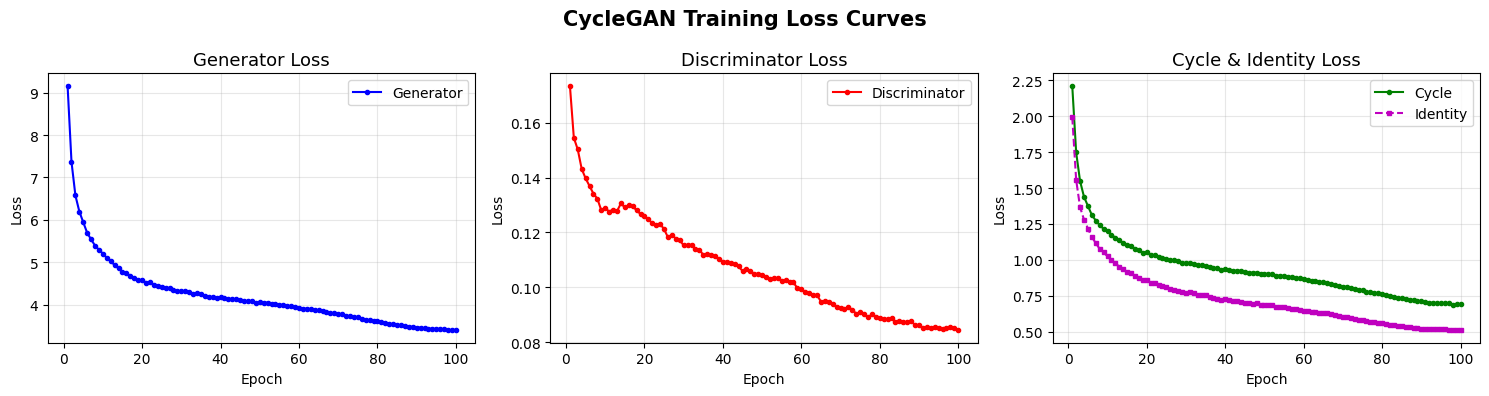

Loss curves saved to training_curves.png


In [ ]:
epochs_range = range(1, len(history['loss_G']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['loss_G'], 'b-o', markersize=3, label='Generator')
axes[0].set_title('Generator Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['loss_D'], 'r-o', markersize=3, label='Discriminator')
axes[1].set_title('Discriminator Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['loss_cycle'],    'g-o',  markersize=3, label='Cycle')
axes[2].plot(epochs_range, history['loss_identity'], 'm--s', markersize=3, label='Identity')
axes[2].set_title('Cycle & Identity Loss', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('CycleGAN Training Loss Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved to training_curves.png')

## 7. Generate Images for Evaluation

In [ ]:
def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().cpu()
    img = (img * 0.5 + 0.5).clamp(0, 1)
    img = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(img)


@torch.no_grad()
def generate_images(generator, src_dir, out_dir, n=300, desc='Generating'):
    generator.eval()
    exts = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG')
    paths = sorted(sum([glob.glob(os.path.join(src_dir, e)) for e in exts], []))
    paths = paths[:n]
    os.makedirs(out_dir, exist_ok=True)

    for idx, p in enumerate(tqdm(paths, desc=desc)):
        img = Image.open(p).convert('RGB')
        x   = infer_transform(img).unsqueeze(0).to(device)
        out = generator(x)
        fname = os.path.splitext(os.path.basename(p))[0] + '.jpg'
        tensor_to_image(out).save(os.path.join(out_dir, fname), quality=95)

    print(f'  Saved {len(paths)} images → {out_dir}')


generate_images(ema_G_A2B, MONET_DIR, PRED_A2B_DIR, n=N_GEN_IMAGES, desc='A2B (Monet→Photo)')
generate_images(ema_G_B2A, PHOTO_DIR, PRED_B2A_DIR, n=N_GEN_IMAGES, desc='B2A (Photo→Monet)')

print('\n✓ All generated images saved. Ready for evaluation script!')

A2B (Monet→Photo): 100%|██████████| 300/300 [00:04<00:00, 64.89it/s]


  Saved 300 images → /content/drive/MyDrive/pred_A2B_kedar


B2A (Photo→Monet): 100%|██████████| 300/300 [00:05<00:00, 56.94it/s]

  Saved 300 images → /content/drive/MyDrive/pred_B2A_kedar

✓ All generated images saved. Ready for evaluation script!


## 8. Visual Inspection

In [ ]:
checkpoint = torch.load("//content/epoch_070.pth", map_location=device)

G_A2B.load_state_dict(checkpoint['G_A2B'])
G_B2A.load_state_dict(checkpoint['G_B2A'])

<All keys matched successfully>

In [ ]:
G_A2B.eval()
G_B2A.eval()

Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): C

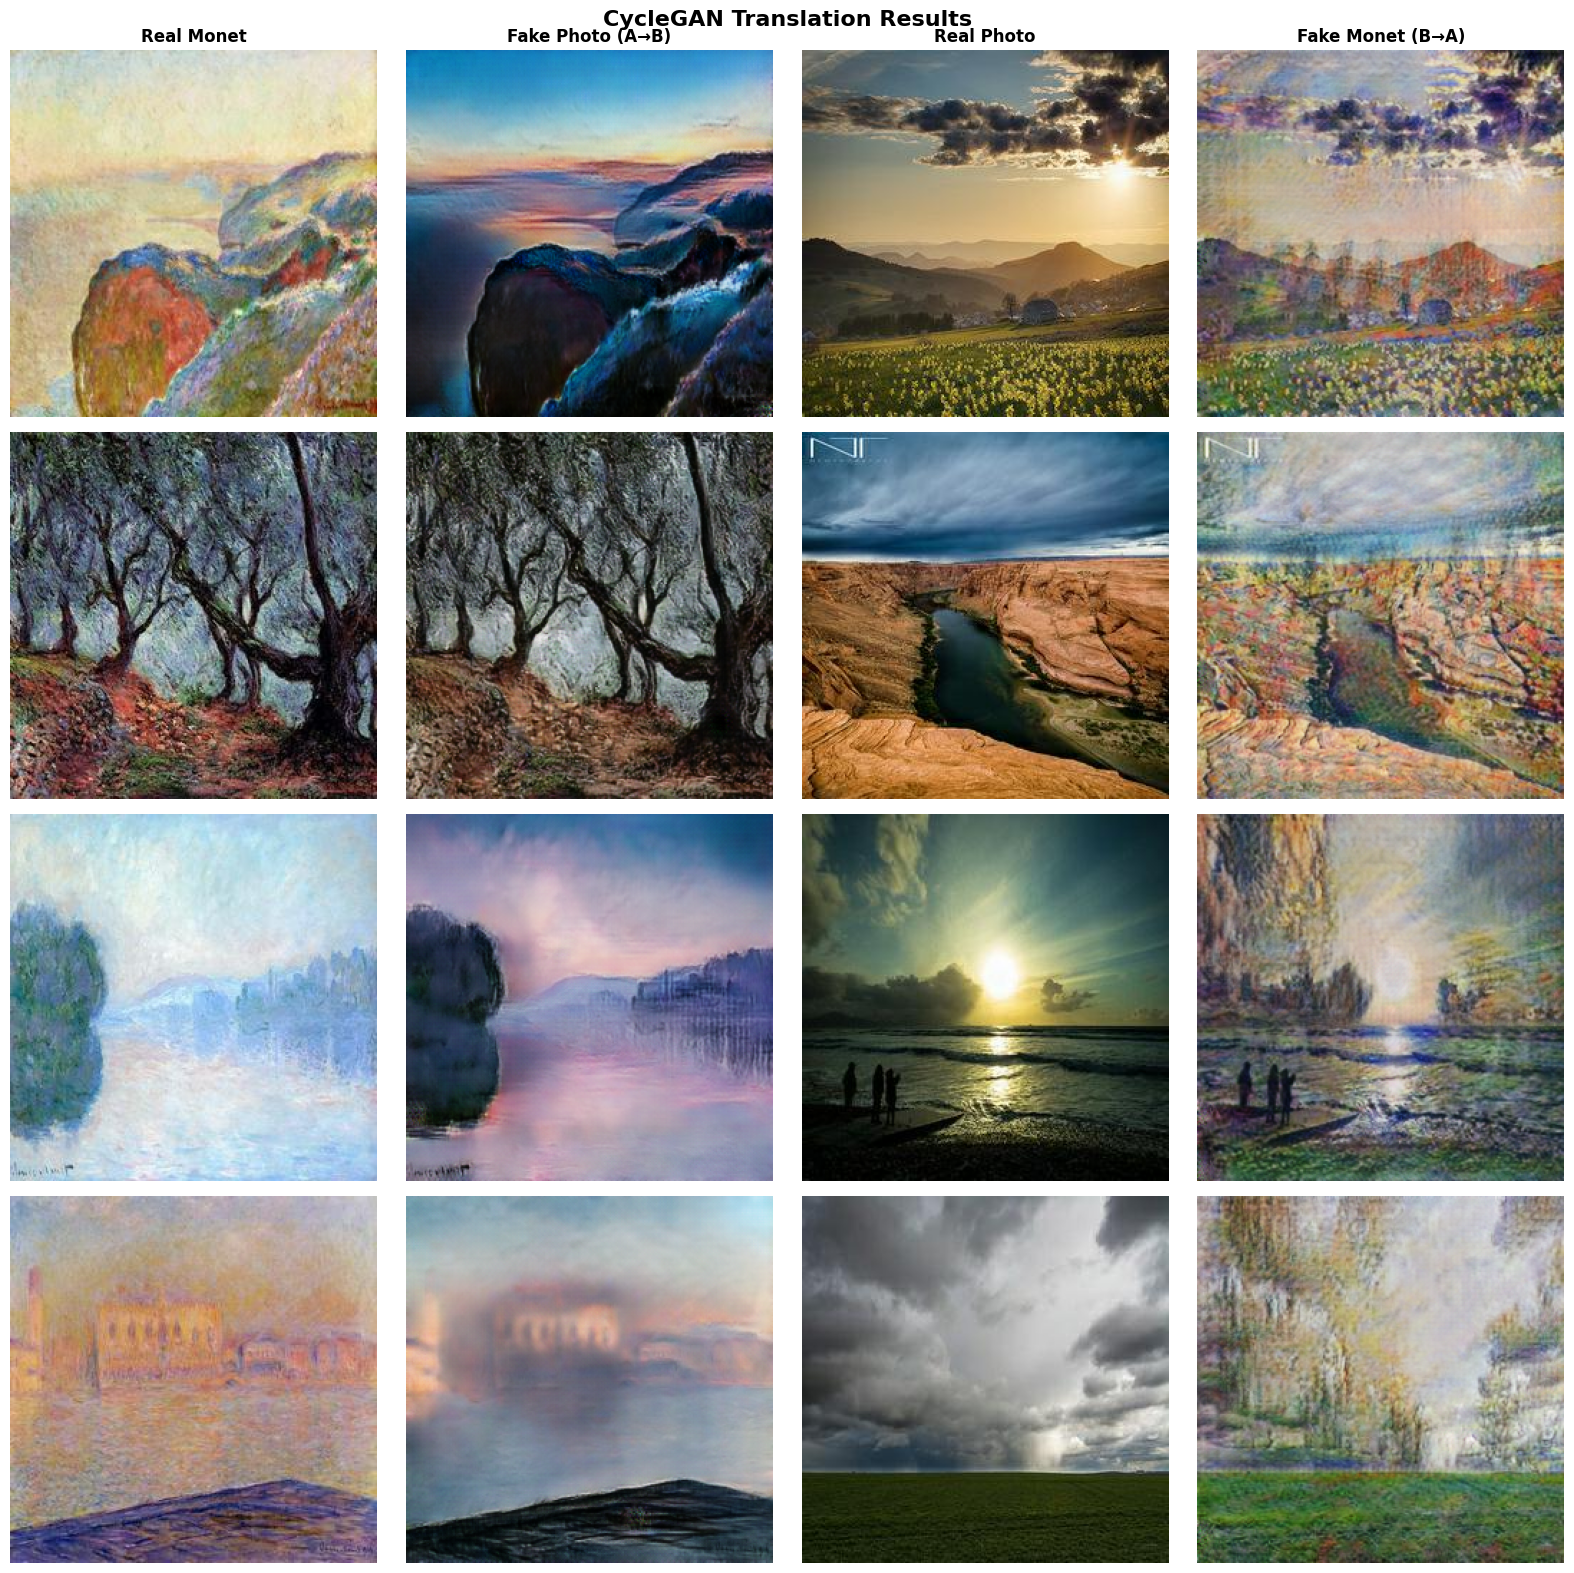

Saved to translation_samples.png


In [ ]:
@torch.no_grad()
def visualise_translations(n_samples=4):
    G_A2B.eval(); G_B2A.eval()

    exts = ('*.jpg','*.jpeg','*.png')
    monet_paths = sorted(sum([glob.glob(os.path.join(MONET_DIR, e)) for e in exts], []))[:n_samples]
    photo_paths = sorted(sum([glob.glob(os.path.join(PHOTO_DIR, e)) for e in exts], []))[:n_samples]

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 4))
    col_titles = ['Real Monet', 'Fake Photo (A→B)', 'Real Photo', 'Fake Monet (B→A)']
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for i in range(n_samples):
        real_A = infer_transform(Image.open(monet_paths[i]).convert('RGB')).unsqueeze(0).to(device)
        real_B = infer_transform(Image.open(photo_paths[i]).convert('RGB')).unsqueeze(0).to(device)

        fake_B = G_A2B(real_A)
        fake_A = G_B2A(real_B)

        imgs = [real_A, fake_B, real_B, fake_A]
        for j, t in enumerate(imgs):
            img = (t.squeeze(0).cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
            axes[i][j].imshow(img)
            axes[i][j].axis('off')

    plt.suptitle('CycleGAN Translation Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('translation_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to translation_samples.png')

visualise_translations(n_samples=4)

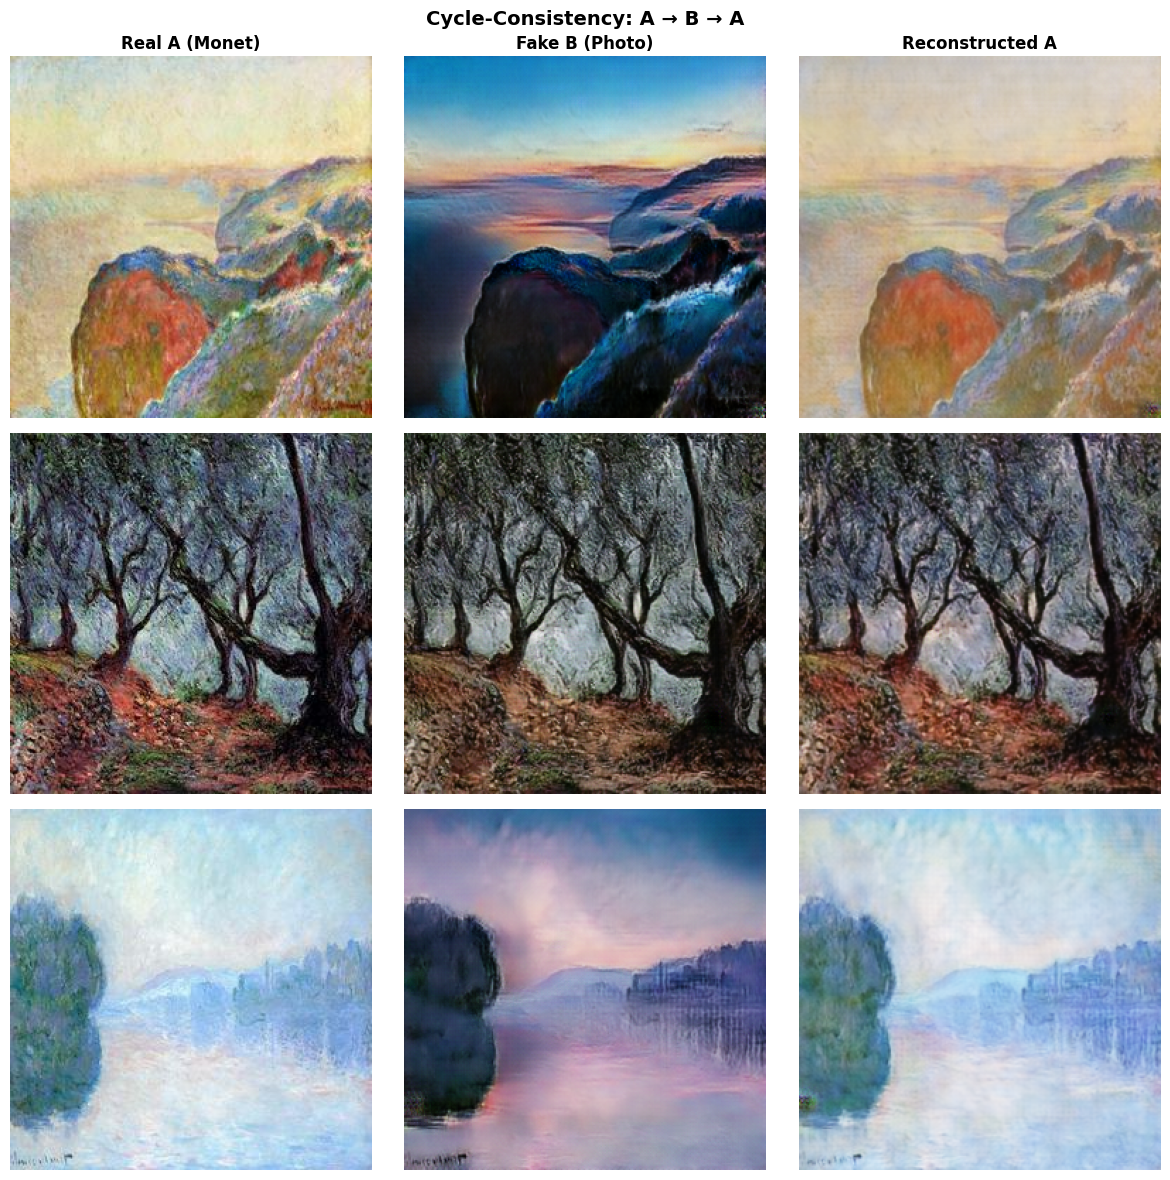

In [ ]:
@torch.no_grad()
def visualise_cycle(n_samples=3):
    G_A2B.eval(); G_B2A.eval()
    exts = ('*.jpg','*.jpeg','*.png')
    monet_paths = sorted(sum([glob.glob(os.path.join(MONET_DIR, e)) for e in exts], []))[:n_samples]

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))
    for ax, t in zip(axes[0], ['Real A (Monet)', 'Fake B (Photo)', 'Reconstructed A']):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for i, p in enumerate(monet_paths):
        real_A = infer_transform(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
        fake_B = G_A2B(real_A)
        rec_A  = G_B2A(fake_B)

        for j, t in enumerate([real_A, fake_B, rec_A]):
            img = (t.squeeze(0).cpu() * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
            axes[i][j].imshow(img)
            axes[i][j].axis('off')

    plt.suptitle('Cycle-Consistency: A → B → A', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cycle_consistency.png', dpi=150, bbox_inches='tight')
    plt.show()

visualise_cycle()